In [47]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

# Plot style
plt.style.use("default")
sns.set_theme(style="whitegrid")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [48]:
df = pd.read_csv(r"C:\Users\admin\Downloads\OneDrive\python\Manufacturing_Production_Efficiency_&_Quality_Analytics\data\raw\manufacturing_defect_dataset.csv")

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


In [49]:
# ==========================================
# Display First Records
# ==========================================

df.head()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


In [50]:
# ==========================================
# Dataset Information
# ==========================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(df.shape)

print("\n")

print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Shape
(3240, 17)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   324

In [51]:
# ==========================================
# Summary Statistics
# ==========================================

df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ProductionVolume,3240.0,548.523148,262.402073,100.000000,322.000000,549.000000,775.250000,999.000000
ProductionCost,3240.0,12423.018476,4308.051904,5000.174521,8728.829280,12405.204656,16124.462428,19993.365549
SupplierQuality,3240.0,89.833290,5.759143,80.004820,84.869219,89.704861,94.789936,99.989214
DeliveryDelay,3240.0,2.558951,1.705804,0.000000,1.000000,3.000000,4.000000,5.000000
DefectRate,3240.0,2.749116,1.310154,0.500710,1.598033,2.708775,3.904533,4.998529
...,...,...,...,...,...,...,...,...
EnergyConsumption,3240.0,2988.494453,1153.420820,1000.720156,1988.140273,2996.822301,3984.788299,4997.074741
EnergyEfficiency,3240.0,0.299776,0.116400,0.100238,0.200502,0.297470,0.402659,0.499500
AdditiveProcessTime,3240.0,5.472098,2.598212,1.000151,3.228507,5.437134,7.741006,9.999749
AdditiveMaterialCost,3240.0,299.515479,116.379905,100.211137,194.922058,299.728918,403.178283,499.982782


In [52]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [53]:
# ==========================================
# Data Types
# ==========================================

df.dtypes

ProductionVolume          int64
ProductionCost          float64
SupplierQuality         float64
DeliveryDelay             int64
DefectRate              float64
                         ...   
EnergyConsumption       float64
EnergyEfficiency        float64
AdditiveProcessTime     float64
AdditiveMaterialCost    float64
DefectStatus              int64
Length: 17, dtype: object

In [54]:
# ==========================================
# Unique Values
# ==========================================

for column in df.columns:
    print(f"\n{column}")
    print("-" * 40)
    print(df[column].nunique())


ProductionVolume
----------------------------------------
862

ProductionCost
----------------------------------------
3240

SupplierQuality
----------------------------------------
3240

DeliveryDelay
----------------------------------------
6

DefectRate
----------------------------------------
3240

QualityScore
----------------------------------------
3240

MaintenanceHours
----------------------------------------
24

DowntimePercentage
----------------------------------------
3240

InventoryTurnover
----------------------------------------
3240

StockoutRate
----------------------------------------
3240

WorkerProductivity
----------------------------------------
3240

SafetyIncidents
----------------------------------------
10

EnergyConsumption
----------------------------------------
3240

EnergyEfficiency
----------------------------------------
3240

AdditiveProcessTime
----------------------------------------
3240

AdditiveMaterialCost
--------------------------------------

In [55]:
# ==========================================
# Random Sample
# ==========================================

df.sample(10, random_state=42)

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
2330,158,15953.737843,84.207442,3,4.101462,79.750780,13,1.799047,3.957913,0.033026,91.941380,5,1416.715355,0.195582,9.476782,290.091740,1
1278,236,18811.499127,90.601047,5,4.976659,88.679076,21,4.944018,5.485262,0.044703,88.869233,8,3289.877417,0.167423,6.645386,199.818223,1
2519,901,13607.987745,83.144713,0,3.401226,85.870998,6,2.758455,5.825024,0.065364,99.578172,7,2264.271160,0.142849,3.672113,245.053103,1
321,740,14797.441858,88.894256,3,4.500916,71.264024,14,4.264748,6.742494,0.071165,88.836971,3,3318.828956,0.264336,6.885332,164.426932,1
2841,755,11227.184810,87.628176,4,4.306916,99.945915,4,2.568002,4.614789,0.043963,97.043180,8,2370.189058,0.174820,3.113864,100.211137,1
1042,194,5819.516300,83.362362,5,0.951027,86.879515,7,1.545963,8.719267,0.098549,92.046683,0,4812.691268,0.213657,6.786119,124.768097,0
1338,114,12546.987088,80.420738,5,4.051852,94.647557,14,2.255270,4.413743,0.080498,96.936831,9,4349.512118,0.176287,8.301736,331.116824,1
1210,745,9066.443806,85.388789,0,3.305443,81.782884,11,1.164491,3.975879,0.077013,95.592762,2,3507.616213,0.155664,1.820481,350.414579,1
1313,625,14963.290775,87.711050,2,1.276958,75.717778,9,2.287736,2.773216,0.075310,93.476670,5,4242.426450,0.180187,7.544463,474.279283,0
2163,370,10954.882433,83.829792,3,2.422414,74.725344,20,4.126695,9.891377,0.099076,85.508932,0,3917.735560,0.487894,3.401747,172.064053,1


In [56]:
print("=" * 70)
print("Dataset Successfully Loaded")
print("Ready for Data Understanding")
print("=" * 70)

Dataset Successfully Loaded
Ready for Data Understanding


In [57]:
import importlib
import src.data_cleaning

importlib.reload(src.data_cleaning)

<module 'src.data_cleaning' from 'c:\\Users\\admin\\Downloads\\OneDrive\\python\\Manufacturing_Production_Efficiency_&_Quality_Analytics\\src\\data_cleaning.py'>

In [58]:
from src.data_cleaning import *

In [59]:
print(clean_dataset)

<function clean_dataset at 0x00000152DD94AC00>


In [60]:
df_clean = clean_dataset(df.copy())

display(df_clean.head())

print(df_clean.shape)

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


(3240, 17)


In [61]:
from src.data_cleaning import *

print(clean_dataset)

<function clean_dataset at 0x00000152DD94AC00>


In [62]:
# Create a cleaned copy of the dataset
df_clean = clean_dataset(df.copy())

print("✅ Data cleaned successfully!")

display(df_clean.head())

print("\nDataset Shape After Cleaning:")
print(df_clean.shape)

✅ Data cleaned successfully!


,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1



Dataset Shape After Cleaning:
(3240, 17)


In [63]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 0


In [64]:
df_clean.isnull().sum()

ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
                       ..
EnergyConsumption       0
EnergyEfficiency        0
AdditiveProcessTime     0
AdditiveMaterialCost    0
DefectStatus            0
Length: 17, dtype: int64

In [65]:
import importlib
import src.data_cleaning

importlib.reload(src.data_cleaning)

from src.data_cleaning import *

In [66]:
iqr_report = detect_outliers_iqr(df_clean)

display(iqr_report)


OUTLIER DETECTION (IQR)


,Column,Outliers
0,ProductionVolume,0
1,ProductionCost,0
2,SupplierQuality,0
3,DeliveryDelay,0
4,DefectRate,0
...,...,...
12,EnergyConsumption,0
13,EnergyEfficiency,0
14,AdditiveProcessTime,0
15,AdditiveMaterialCost,0


In [71]:
import pandas as pd
import numpy as np
from scipy import stats

In [72]:
import importlib
import src.data_cleaning

importlib.reload(src.data_cleaning)

<module 'src.data_cleaning' from 'c:\\Users\\admin\\Downloads\\OneDrive\\python\\Manufacturing_Production_Efficiency_&_Quality_Analytics\\src\\data_cleaning.py'>

In [73]:
from src.data_cleaning import *

In [74]:
import src.data_cleaning

print(hasattr(src.data_cleaning, "np"))

False


In [75]:
import src.data_cleaning

print(src.data_cleaning.__file__)

c:\Users\admin\Downloads\OneDrive\python\Manufacturing_Production_Efficiency_&_Quality_Analytics\src\data_cleaning.py


In [76]:
import src.data_cleaning

print(src.data_cleaning.__file__)

c:\Users\admin\Downloads\OneDrive\python\Manufacturing_Production_Efficiency_&_Quality_Analytics\src\data_cleaning.py


In [77]:
import src.data_cleaning

print("Has np:", hasattr(src.data_cleaning, "np"))
print("Has stats:", hasattr(src.data_cleaning, "stats"))

Has np: False
Has stats: False


In [78]:
with open(src.data_cleaning.__file__, "r") as f:
    for i in range(5):
        print(f.readline(), end="")

import pandas as pd

def clean_dataset(df):
    """
    Perform basic data cleaning.


In [79]:
import importlib
import src.data_cleaning

importlib.reload(src.data_cleaning)

from src.data_cleaning import *

In [80]:
import src.data_cleaning

print("Has np:", hasattr(src.data_cleaning, "np"))
print("Has stats:", hasattr(src.data_cleaning, "stats"))

Has np: False
Has stats: False


In [81]:
import src.data_cleaning

In [82]:
import src.data_cleaning

print(src.data_cleaning.__file__)

c:\Users\admin\Downloads\OneDrive\python\Manufacturing_Production_Efficiency_&_Quality_Analytics\src\data_cleaning.py


In [83]:
import inspect
import src.data_cleaning

print(inspect.getsource(src.data_cleaning)[:300])

import pandas as pd
import numpy as np
from scipy import stats

print("✅ data_cleaning.py Loaded")
def clean_dataset(df):
    """
    Perform basic data cleaning.
    """

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Remove rows with all missing values
    df = df.dropna(how="all


In [84]:
import importlib
import src.eda

importlib.reload(src.eda)

from src.eda import *

In [85]:
df_eda = df_clean.copy()

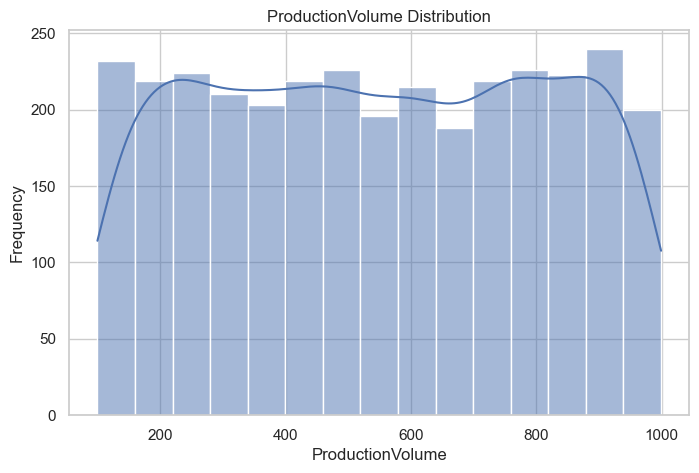

In [86]:
plot_histogram(df_eda, "ProductionVolume")

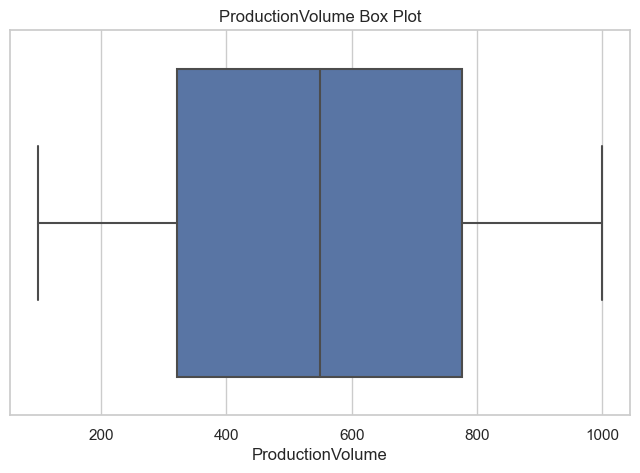

In [88]:
plot_boxplot(df_eda, "ProductionVolume")

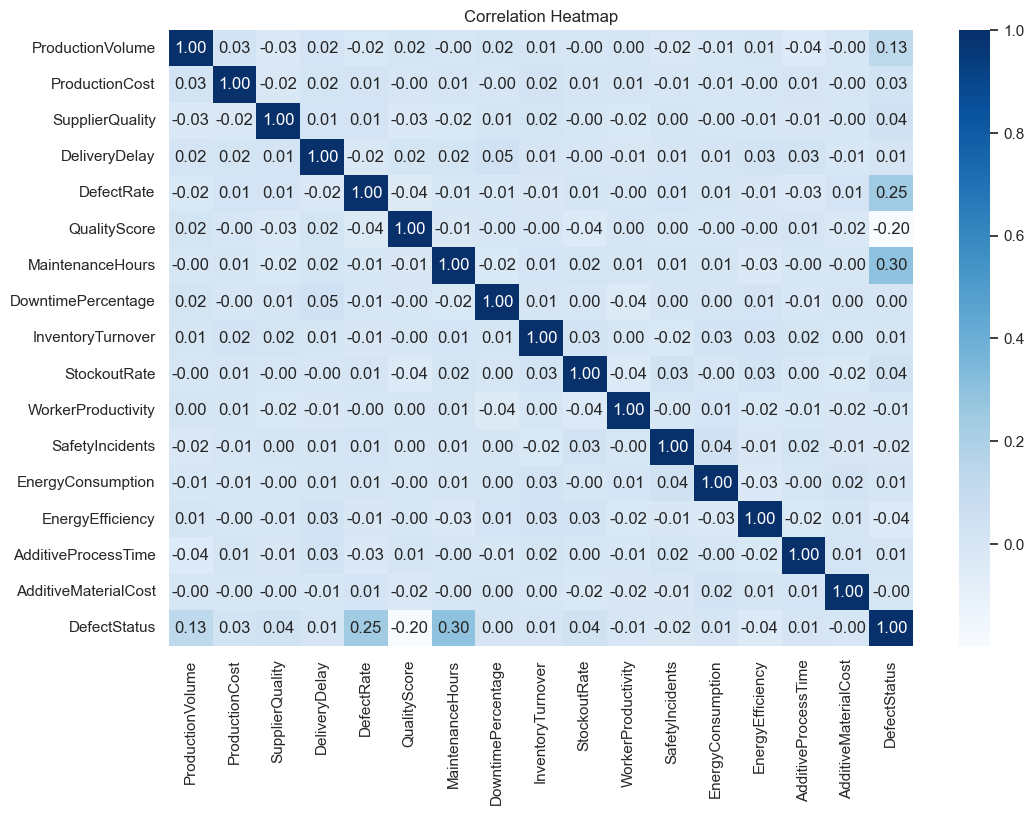

In [89]:
correlation_heatmap(df_eda)

In [90]:
import importlib
import src.feature_engineering

importlib.reload(src.feature_engineering)

from src.feature_engineering import *

In [91]:
df_features = create_features(df_clean)

display(df_features.head())

✅ Feature Engineering Completed.


,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus,Production_Efficiency,Defect_Percentage,Machine_Utilization,Productivity_Score,Machine_Health,Risk_Category
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1,0.02,312.15,0.08,12819.63,Excellent,High
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1,0.03,81.95,0.14,44778.33,Good,High
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1,0.05,451.45,0.28,86736.53,Excellent,High
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1,0.07,63.85,0.08,25022.62,Excellent,High
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1,0.03,386.78,0.13,17042.04,Excellent,High


In [92]:
new_columns = [
    "Production_Efficiency",
    "Defect_Percentage",
    "Machine_Utilization",
    "Productivity_Score",
    "Machine_Health",
    "Risk_Category"
]

display(df_features[new_columns].head())

,Production_Efficiency,Defect_Percentage,Machine_Utilization,Productivity_Score,Machine_Health,Risk_Category
0,0.02,312.15,0.08,12819.63,Excellent,High
1,0.03,81.95,0.14,44778.33,Good,High
2,0.05,451.45,0.28,86736.53,Excellent,High
3,0.07,63.85,0.08,25022.62,Excellent,High
4,0.03,386.78,0.13,17042.04,Excellent,High


In [94]:
save_feature_dataset(
    df_features,
    "../data/raw/manufacturing_feature_engineered.csv"
)

Dataset saved to:
../data/raw/manufacturing_feature_engineered.csv
